In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, classification_report
from imblearn.over_sampling import SMOTE
import optuna

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression


## 1. Load Data & Handling Missing Values


In [2]:
df = pd.read_csv('wine_quality_dataset.csv')
print(f"Shape: {df.shape}")
display(df.head())

Shape: (6497, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64


In [4]:
# Xử lý missing values bằng cách điền Median cho các cột số
num_cols_with_na = df.columns[df.isnull().any()].tolist()
for col in num_cols_with_na:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    
print("\nSau khi handle missing values:")
print(df.isnull().sum().max())


Sau khi handle missing values:
0


## 2. EDA


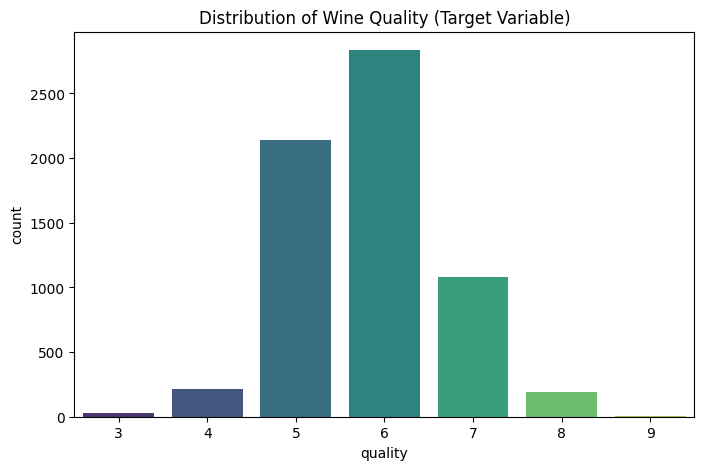

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quality', palette='viridis')
plt.title('Distribution of Wine Quality (Target Variable)')
plt.show()

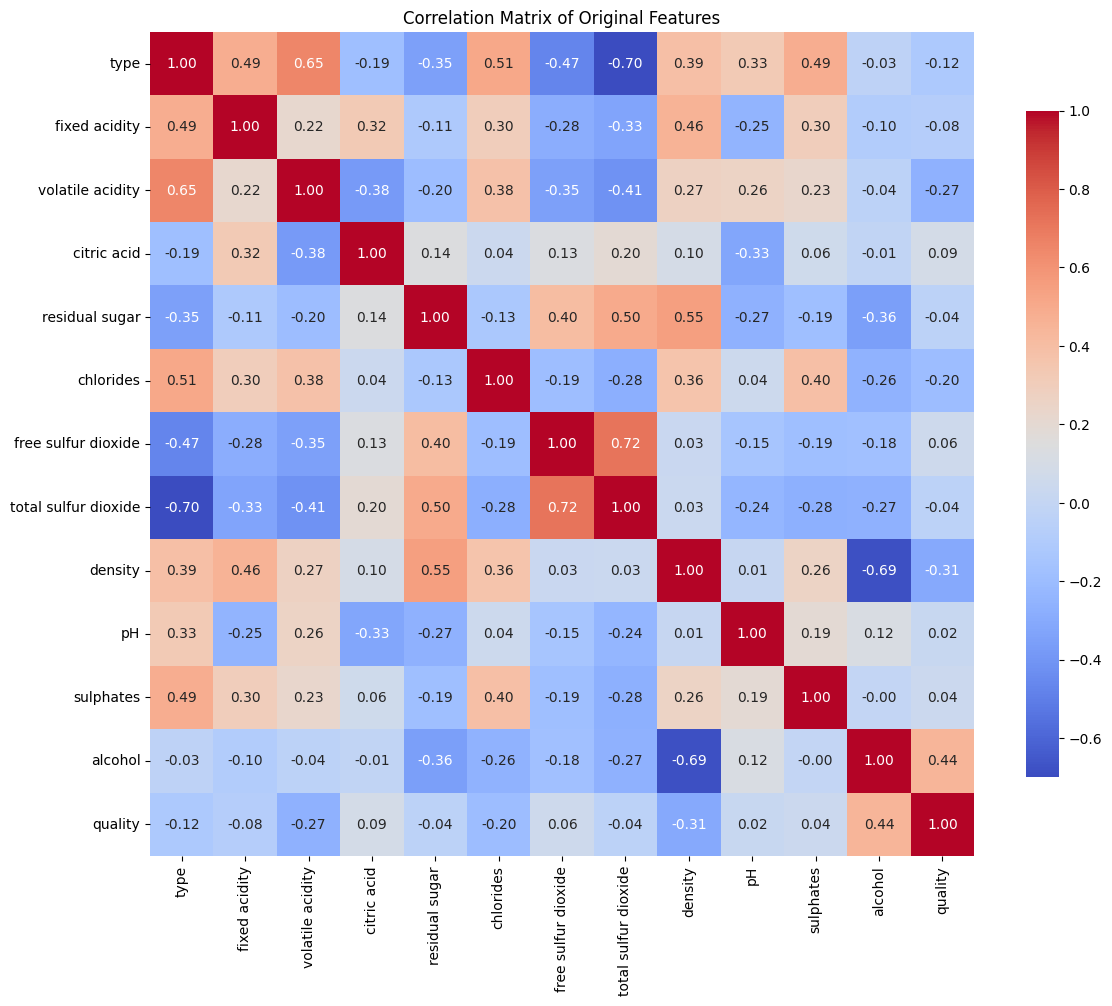

In [6]:
plt.figure(figsize=(12, 10))
df_temp = df.copy()
df_temp['type'] = df_temp['type'].map({'white': 0, 'red': 1})
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Original Features')
plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [7]:
def create_safe_wine_features(df_input):
    df_engineered = df_input.copy()
    
    # 1. Ratio features (thêm 1e-8 để tránh chia cho 0)
    df_engineered['acid ratio'] = df_engineered['fixed acidity'] / (df_engineered['volatile acidity'] + 1e-8)
    df_engineered['sulfur ratio'] = df_engineered['free sulfur dioxide'] / (df_engineered['total sulfur dioxide'] + 1e-8)
    df_engineered['alcohol sugar ratio'] = df_engineered['alcohol'] / (df_engineered['residual sugar'] + 1e-8)
    
    # 2. Interaction features
    df_engineered['density alcohol interaction'] = df_engineered['density'] * df_engineered['alcohol']
    df_engineered['sulphates alcohol'] = df_engineered['sulphates'] * df_engineered['alcohol']
    
    # 3. Polynomial features
    df_engineered['alcohol squared'] = df_engineered['alcohol'] ** 2
    df_engineered['volatile acidity squared'] = df_engineered['volatile acidity'] ** 2
    
    # 4. Logarithmic features
    df_engineered['log volatile acidity'] = np.log1p(df_engineered['volatile acidity'])
    df_engineered['log residual sugar'] = np.log1p(df_engineered['residual sugar'])
    df_engineered['log chlorides'] = np.log1p(df_engineered['chlorides'])
    
    # 5. Quality Score 
    df_engineered['quality score'] = (
        df_engineered['alcohol'] * 0.35 +
        (1 / (df_engineered['volatile acidity'] + 1e-8)) * 0.20 +
        df_engineered['sulphates'] * 0.20 +
        df_engineered['citric acid'] * 0.15 +
        (1 / (df_engineered['chlorides'] + 1e-8)) * 0.10
    )
    
    # Encode 'type'
    if 'type' in df_engineered.columns:
        df_engineered['type'] = df_engineered['type'].map({'white': 0, 'red': 1})
        
    return df_engineered

df_engineered = create_safe_wine_features(df)
print(f"Tổng số features sau FE: {df_engineered.shape[1] - 1}")


Tổng số features sau FE: 23


## 4. Feature Selection
Tìm các features tương quan cao nhất với `quality`.

Original Classes: [3 4 5 6 7 8 9]
Encoded Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


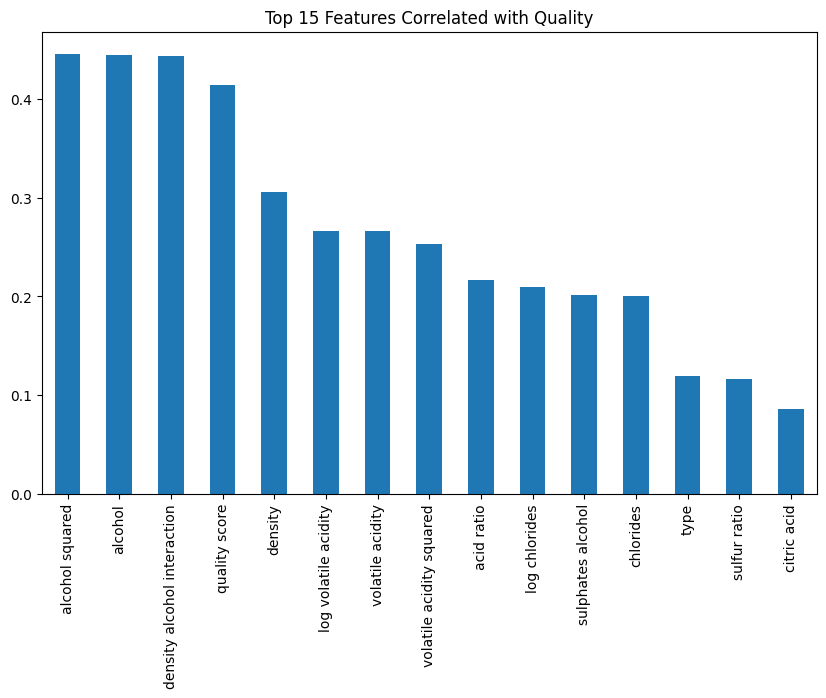

Selected valid features: ['alcohol squared', 'alcohol', 'density alcohol interaction', 'quality score', 'density', 'log volatile acidity', 'volatile acidity', 'volatile acidity squared', 'acid ratio', 'log chlorides', 'sulphates alcohol', 'chlorides', 'type', 'sulfur ratio', 'citric acid']


In [8]:
# Tách Features & Target
X = df_engineered.drop('quality', axis=1)
y = df_engineered['quality']

# Encode biến mục tiêu về dạng 0 -> N-1 (bắt buộc cho XGBoost/CatBoost classification)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Original Classes: {label_encoder.classes_}")
print(f"Encoded Classes: {sorted(set(y_encoded))}")

# Tính correlation
feature_correlation = X.corrwith(y).abs().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_correlation.head(15).plot(kind='bar')
plt.title('Top 15 Features Correlated with Quality')
plt.show()

# Chọn Top 15 features
top_features = feature_correlation.head(15).index.tolist()
X_selected = X[top_features]
print("Selected valid features:", top_features)


## 5. Train/Test Split and SMOTE


In [9]:
from sklearn.impute import SimpleImputer

# 1. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 2. Handle missing values (fit only on train)
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 4. SMOTE (train only)
min_class_count = pd.Series(y_train).value_counts().min()
k_neighbors = min(3, min_class_count - 1) if min_class_count > 1 else 1

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

## 6. Modeling & Hyperparameter Tuning (Optuna)


In [10]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optimize_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 10, 30, step=5),
        'random_state': 42,
        'class_weight': 'balanced',
        'n_jobs': -1
    }
    # Cross val on train after smote
    clf = RandomForestClassifier(**params)
    return cross_val_score(clf, X_train_resampled, y_train_resampled, cv=3, scoring='f1_macro', n_jobs=-1).mean()

# Optimize with Optuna
print("Optimizing Random Forest...")
study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(optimize_rf, n_trials=5) # can up to 30-50 to improve quality
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, class_weight='balanced')
best_rf.fit(X_train_resampled, y_train_resampled)
print("Best RF Valid F1:", study_rf.best_value)

Optimizing Random Forest...


Best RF Valid F1: 0.8792949919331191


In [11]:
# Extra Trees Model 
best_et = ExtraTreesClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight='balanced', n_jobs=-1)
best_et.fit(X_train_resampled, y_train_resampled)

# XGBoost Model
best_xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, 
                         objective='multi:softprob', random_state=42, n_jobs=-1)
best_xgb.fit(X_train_resampled, y_train_resampled)

# CatBoost Model
cat_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, 
                               random_seed=42, verbose=False, auto_class_weights='Balanced')
cat_model.fit(X_train_resampled, y_train_resampled)

print("Trained ET, XGB, CatBoost models successfully.")


Trained ET, XGB, CatBoost models successfully.


## 7. Ensemble Modeling: Stacking & Blending

In [12]:
print(">> STACKING CLASSIFIER")
stacking_clf = StackingClassifier(
    estimators=[('rf', best_rf), ('et', best_et), ('xgb', best_xgb)],
    final_estimator=LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=500),
    cv=3, n_jobs=-1
)
stacking_clf.fit(X_train_resampled, y_train_resampled)
print("Stacking fit complete.")

print("\n>> BLENDING METHOD")
# Lấy predict_proba của tập TRAIN
rf_train_proba = best_rf.predict_proba(X_train_resampled)
et_train_proba = best_et.predict_proba(X_train_resampled)
xgb_train_proba = best_xgb.predict_proba(X_train_resampled)
blend_X_train = np.hstack((rf_train_proba, et_train_proba, xgb_train_proba))

blend_model = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=500, random_state=42)
blend_model.fit(blend_X_train, y_train_resampled)
print("Blending fit complete.")


>> STACKING CLASSIFIER
Stacking fit complete.

>> BLENDING METHOD
Blending fit complete.


## 8. Evaluation on Test Set


In [13]:
def evaluate_model(name, model, is_blend=False):
    if is_blend:
        rf_test_proba = best_rf.predict_proba(X_test_scaled)
        et_test_proba = best_et.predict_proba(X_test_scaled)
        xgb_test_proba = best_xgb.predict_proba(X_test_scaled)
        blend_X_test = np.hstack((rf_test_proba, et_test_proba, xgb_test_proba))
        preds_encoded = model.predict(blend_X_test)
    else:
        preds_encoded = model.predict(X_test_scaled)
        
    f1 = f1_score(y_test, preds_encoded, average='macro')
    return f1

results = {
    'Random Forest': evaluate_model('RF', best_rf),
    'Extra Trees': evaluate_model('ET', best_et),
    'XGBoost': evaluate_model('XGB', best_xgb),
    'CatBoost': evaluate_model('CAT', cat_model),
    'Stacking': evaluate_model('Stacking', stacking_clf),
    'Blending': evaluate_model('Blending', blend_model, is_blend=True)
}

print("=== FINAL TEST SET PERFORMANCE (F1 Macro) ===")
for model_name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:15s} : {score:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name}")

=== FINAL TEST SET PERFORMANCE (F1 Macro) ===
Stacking        : 0.3865
Blending        : 0.3859
Extra Trees     : 0.3827
Random Forest   : 0.3755
XGBoost         : 0.3433
CatBoost        : 0.2834

Best Model: Stacking


In [ ]:
import os
import joblib

if not os.path.exists('models'):
    os.makedirs('models')

print("Saving preprocessing objects...")
joblib.dump(imputer, 'models/imputer.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(label_encoder, 'models/label_encoder.joblib')
joblib.dump(top_features, 'models/top_features.joblib')

print("Saving models...")
# Always save the best base models in case they are needed for blending
joblib.dump(best_rf, 'models/best_rf.joblib')
joblib.dump(best_et, 'models/best_et.joblib')
joblib.dump(best_xgb, 'models/best_xgb.joblib')

if best_model_name == 'Random Forest':
    best_model_obj = best_rf
elif best_model_name == 'Extra Trees':
    best_model_obj = best_et
elif best_model_name == 'XGBoost':
    best_model_obj = best_xgb
elif best_model_name == 'CatBoost':
    best_model_obj = cat_model
elif best_model_name == 'Stacking':
    best_model_obj = stacking_clf
elif best_model_name == 'Blending':
    best_model_obj = blend_model

if best_model_name in ['Random Forest', 'Extra Trees', 'XGBoost', 'CatBoost', 'Stacking', 'Blending']:
    joblib.dump(best_model_obj, 'models/best_model.joblib')
    
# Write a tiny metadata file for app.py
with open('models/metadata.txt', 'w') as f:
    f.write(best_model_name)

print("Export complete! Files saved in 'models/' directory.")
